In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install transformers datasets accelerate evaluate sacrebleu sentencepiece



In [ ]:
import transformers
print(transformers.__version__)


5.0.0


In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
import evaluate

from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)


In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

# ============================
# 1) Load Excel
# ============================
df = pd.read_excel("/content/my_dataset.xlsx")

# Rename first two columns -> src/tgt
df = df.rename(columns={
    df.columns[0]: "src",
    df.columns[1]: "tgt",
})

df = df[["src", "tgt"]]

# ============================
# 2) Cleaning
# ============================
df = df.dropna(subset=["src", "tgt"])
df["src"] = df["src"].astype(str).str.strip()
df["tgt"] = df["tgt"].astype(str).str.strip()

# remove empty rows
df = df[(df["src"] != "") & (df["tgt"] != "")]

# remove duplicates (exact pair duplicates)
df = df.drop_duplicates(subset=["src", "tgt"]).reset_index(drop=True)

print(f"Total sentence pairs: {len(df)}")

# ============================
# 3) Convert to HF Dataset
# ============================
dataset = Dataset.from_pandas(df, preserve_index=False)

# ============================
# 4) Random Split (80/10/10)
# ============================
SEED = 42

# 80% train, 20% temp
split_80_20 = dataset.train_test_split(test_size=0.2, seed=SEED, shuffle=True)

# split the 20% into 10% val and 10% test
split_val_test = split_80_20["test"].train_test_split(test_size=0.5, seed=SEED, shuffle=True)

datasets = DatasetDict({
    "train": split_80_20["train"],
    "validation": split_val_test["train"],
    "test": split_val_test["test"],
})

print(
    f"Train: {len(datasets['train'])} | "
    f"Val: {len(datasets['validation'])} | "
    f"Test: {len(datasets['test'])}"
)

# (optional) show one example
print("Train example:", datasets["train"][0])


Total sentence pairs: 8768
Train: 7014 | Val: 877 | Test: 877
Train example: {'src': 'medudream maran.Hwilum mæru cwen,', 'tgt': 'In any hall on earth.  Sometimes the queen'}


In [ ]:
model_name = "facebook/mbart-large-50-many-to-many-mmt"

tokenizer = MBart50TokenizerFast.from_pretrained(model_name)

# OE → ME
tokenizer.src_lang = "en_XX"     # Old English
tokenizer.tgt_lang = "en_XX"   # Modern English

model = MBartForConditionalGeneration.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

In [ ]:
max_source_length = 128
max_target_length = 128

def preprocess_function(examples):
    inputs = examples["src"]
    targets = examples["tgt"]

    # Source tokenize
    model_inputs = tokenizer(
        inputs,
        max_length=max_source_length,
        truncation=True,
    )

    # Target tokenize (NO as_target_tokenizer)
    labels = tokenizer(
        text_target=targets,
        max_length=max_target_length,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_data = datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=datasets["train"].column_names,
)


Map:   0%|          | 0/7014 [00:00<?, ? examples/s]

Map:   0%|          | 0/877 [00:00<?, ? examples/s]

Map:   0%|          | 0/877 [00:00<?, ? examples/s]

In [ ]:
sacrebleu = evaluate.load("sacrebleu")

def postprocess_text(texts):
    return [t.strip() for t in texts]

def compute_metrics(eval_preds):
    preds, labels = eval_preds

    if isinstance(preds, tuple):
        preds = preds[0]

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = postprocess_text(decoded_preds)
    decoded_labels = postprocess_text(decoded_labels)

    result = sacrebleu.compute(
        predictions=decoded_preds,
        references=[[l] for l in decoded_labels],
    )

    return {"bleu": result["score"]}


In [ ]:
from transformers import Seq2SeqTrainingArguments, EarlyStoppingCallback

output_dir = "/content/drive/MyDrive/mBART_new/OE2ME_models"

training_args = Seq2SeqTrainingArguments(
    output_dir=output_dir,

    # ===== Eval/Save =====
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,

    # ===== Overfitting control =====
    num_train_epochs=10,          # allow training, but early stopping will stop earlier
    learning_rate=2e-5,           # slightly lower than 3e-5
    weight_decay=0.01,
    label_smoothing_factor=0.1,
    warmup_ratio=0.06,

    # ===== Throughput (H100) =====
    bf16=True,
    per_device_train_batch_size=32,   # H100 can usually handle this (adjust if OOM)
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,    # keep it 1 for speed on H100

    # ===== Generation for metrics =====
    predict_with_generate=True,
    generation_max_length=128,
    generation_num_beams=4,           # if eval slow, set to 2

    # ===== Efficiency =====
    group_by_length=True,

    # ===== Logging =====
    logging_steps=50,
    report_to="none",
    seed=42,
)

# Use this callback in your trainer
early_stop_cb = EarlyStoppingCallback(early_stopping_patience=2)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainer

# 1. Data collator
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
)

# 2. Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_data["train"],
    eval_dataset=tokenized_data["validation"],
    processing_class=tokenizer,   # 🔥 replace tokenizer=
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stop_cb],
)



In [ ]:
trainer.train()


Epoch,Training Loss,Validation Loss,Bleu
1,4.063363,4.058576,14.203358
2,3.658555,3.663012,20.330485
3,3.224807,3.572985,23.157381
4,3.077228,3.549975,24.999739
5,2.984787,3.564300,25.825746
6,2.865233,3.564701,25.980151
7,2.730278,3.642710,26.438485
8,2.530588,3.671625,26.894227
9,2.602793,3.711534,26.559095
10,2.477890,3.726168,26.594071


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=2200, training_loss=3.092489568536932, metrics={'train_runtime': 704.8847, 'train_samples_per_second': 99.506, 'train_steps_per_second': 3.121, 'total_flos': 8666377338028032.0, 'train_loss': 3.092489568536932, 'epoch': 10.0})

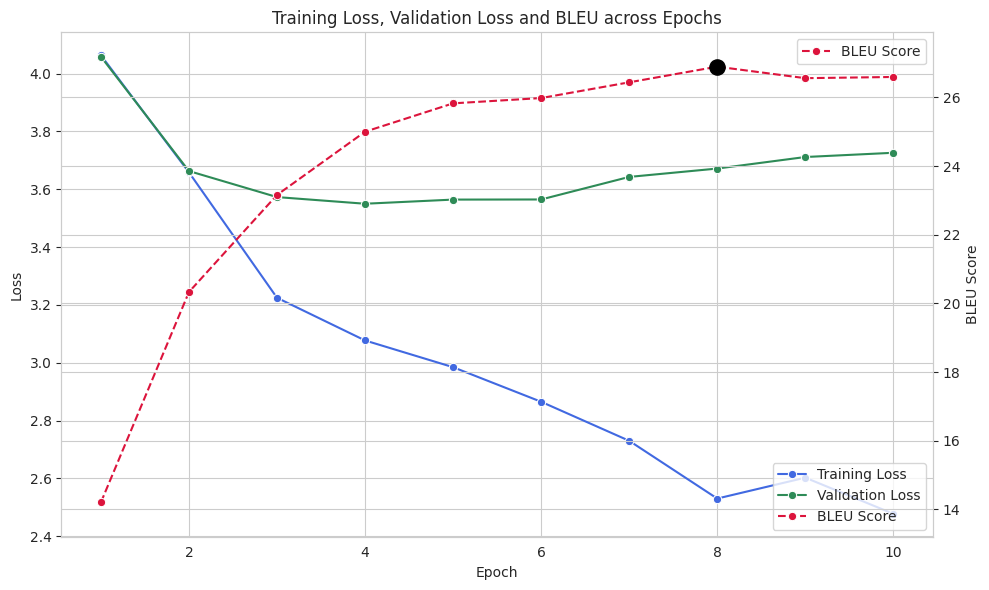

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# Data (Epoch 1–10)
# ============================
data = {
    "Epoch": list(range(1, 11)),
    "Training_Loss": [
        4.063363, 3.658555, 3.224807, 3.077228,
        2.984787, 2.865233, 2.730278, 2.530588,
        2.602793, 2.477890
    ],
    "Validation_Loss": [
        4.058576, 3.663012, 3.572985, 3.549975,
        3.564300, 3.564701, 3.642710, 3.671625,
        3.711534, 3.726168
    ],
    "BLEU": [
        14.203358, 20.330485, 23.157381, 24.999739,
        25.825746, 25.980151, 26.438485, 26.894227,
        26.559095, 26.594071
    ]
}

df = pd.DataFrame(data)

sns.set_style("whitegrid")

fig, ax1 = plt.subplots(figsize=(10, 6))

# 🔵 Training Loss
sns.lineplot(
    data=df, x="Epoch", y="Training_Loss",
    marker="o", color="royalblue",
    ax=ax1, label="Training Loss"
)

# 🟢 Validation Loss
sns.lineplot(
    data=df, x="Epoch", y="Validation_Loss",
    marker="o", color="seagreen",
    ax=ax1, label="Validation Loss"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

# Secondary axis for BLEU
ax2 = ax1.twinx()

# 🔴 BLEU
sns.lineplot(
    data=df, x="Epoch", y="BLEU",
    marker="o", linestyle="--",
    color="crimson",
    ax=ax2, label="BLEU Score"
)

ax2.set_ylabel("BLEU Score")

# Ensure BLEU max visible
ax2.set_ylim(min(df["BLEU"]) - 1, max(df["BLEU"]) + 1)

# Highlight best BLEU
best_idx = df["BLEU"].idxmax()
ax2.scatter(
    df["Epoch"][best_idx],
    df["BLEU"][best_idx],
    color="black",
    s=120,
    zorder=5
)

# Combine legends
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")

plt.title("Training Loss, Validation Loss and BLEU across Epochs")
plt.tight_layout()
plt.show()


In [ ]:
print("Evaluating on test set...")
test_metrics = trainer.evaluate(tokenized_data["test"])
print(test_metrics)



# Save BEST model inside output_dir
best_model_path = f"{output_dir}/best_model"
trainer.save_model(best_model_path)


Evaluating on test set...


{'eval_loss': 3.7570035457611084, 'eval_bleu': 26.329623680596765, 'eval_runtime': 17.6381, 'eval_samples_per_second': 49.722, 'eval_steps_per_second': 1.587, 'epoch': 10.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]